In [ ]:
# ON HPC

#library(arrow)
library(ggplot2)
#library(qvalue)
library(vroom)
library(dplyr)

# CT Results
# Summary of leads: 
#   - paste0(indir,cell.type,'.qvalue.cis_qtl.txt.gz') 
#   - ex: /nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/05_caQTLs/outs/Endothelial.qvalue.cis_qtl.txt.gz
# Full summary stats: 
#   - paste0(outdir, cell.type, '.cis_qtl_pairs.chr.qvalue.tsv')
#   - ex: /nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/05_caQTLs/outs/Endothelial.cis_qtl_pairs.chr.qvalue.tsv
# Significant summary stats: 
#   - paste0(outdir, cell.type, '.cis_qtl_pairs.chr.qvalue.sig.tsv')
#   - ex: /nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/05_caQTLs/outs/Endothelial.cis_qtl_pairs.chr.qvalue.sig.tsv

indir <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/05_caQTLs/outs/'
outdir <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/tensorQTL/05_caQTLs/outs/'
unique_cell_types <- c('Endothelial', 'Hepatocytes', 'T', 'HSC', 'Cholangiocyte', 'Myeloid', 'NK', 'B', 'Bulk')

summary.df <- NULL

for (cell.type in unique_cell_types) {
    bulk.comparisons <- 0
    bulk.sig <- 0
    message(paste0("Start of ", cell.type," - ", Sys.time()))
    leads <- vroom(paste0(indir,cell.type,'.cis_qtl.txt.gz'), show_col_types=FALSE)
    message(paste0("Number of QTL.Features for ", cell.type,": ", sum(leads$qval < 0.05)))
    
    ct.res <- data.frame()
    for (i in 1:22) {
        message(paste0(cell.type," chr",i," - ", Sys.time()))
        chr.res <- vroom(paste0(indir,'tsv.test/',cell.type,'.cis_qtl_pairs.chr',i,'.parquet.tsv'), show_col_types=FALSE)
        chr.res$sig.qtl <- FALSE
        
        if ('pval_nominal_threshold' %in% colnames(leads)) {
            chr.res <- left_join(chr.res, select(leads, phenotype_id, pval_nominal_threshold), join_by(phenotype_id))
            chr.res$sig.qtl <- chr.res$pval_nominal < chr.res$pval_nominal_threshold
        }
        
        message(paste0("Comparisons for ", cell.type, ' chr',i,": ", nrow(chr.res)))
        message(paste0("Significant comparisons for ", cell.type, ' chr',i,": ", sum(chr.res$sig.qtl)))
        
        bulk.comparisons <- bulk.comparisons + nrow(chr.res)
        bulk.sig <- bulk.sig + sum(chr.res$sig.qtl)
        
        if (cell.type != 'Bulk') {
            ct.res <- rbind(ct.res, chr.res)
        }
        gc()
    }
    
    #write.table(ct.res, paste0(outdir, cell.type, '.cis_qtl_pairs.chr.qvalue.tsv'),
    #       sep='\t', col.names=T, row.names=F, quote=F)
    #write.table(filter(ct.res, sig.qtl), paste0(outdir, cell.type, '.cis_qtl_pairs.chr.qvalue.sig.tsv'),
    #           sep='\t', col.names=T, row.names=F, quote=F)
    
    message(paste0("End of ", cell.type," - ", Sys.time()))
    
    if (cell.type != 'Bulk') {
        message(paste0("Comparisons for ", cell.type, ": ", nrow(ct.res)))
        message(paste0("Significant comparisons for ", cell.type, ": ", sum(ct.res$sig.qtl)))
        summary.df <- rbind(summary.df, data.frame(cell=cell.type, features=nrow(leads), features.sig=sum(leads$qval < 0.05),
                          tests=nrow(ct.res), tests.sig=sum(ct.res$sig.qtl)))
    } else {
        message(paste0("Comparisons for ", cell.type, ": ", bulk.comparisons))
        message(paste0("Significant comparisons for ", cell.type, ": ", bulk.sig))
        summary.df <- rbind(summary.df, data.frame(cell=cell.type, features=nrow(leads), features.sig=sum(leads$qval < 0.05),
                          tests=bulk.comparisons, tests.sig=bulk.sig))
    }
    
    
    
    
    ct.res <- NULL
    leads <- NULL
    gc()
}
summary.df

write.table(summary.df, paste0(outdir, 'caQTL.summary.tsv'),
           quote=F, row.names=F, col.names=T, sep='\t')

Start of Endothelial - 2024-09-29 15:21:35.635802

Number of QTL.Features for Endothelial: 1858

Endothelial chr1 - 2024-09-29 15:21:36.128006

Comparisons for Endothelial chr1: 43338019

Significant comparisons for Endothelial chr1: 7066

Endothelial chr2 - 2024-09-29 15:22:21.599078



In [13]:
library(ggplot2)
library(dplyr)

In [15]:
summary.df <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/05_caQTLs/outs/caQTL.summary.tsv', header=T)
summary.df

cell,features,features.sig,tests,tests.sig
<chr>,<int>,<int>,<dbl>,<int>
Endothelial,144545,1855,563384880,118509
Hepatocytes,538131,6106,2122940846,431981
T,25183,54,94648391,3024
HSC,113189,443,443283389,28138
Cholangiocyte,44523,64,171935060,3050
Myeloid,167122,2047,649658272,138250
NK,21178,16,79327065,1357
B,20339,6,76205498,637
Bulk,592835,7299,2351559812,520153


In [16]:
celltype_colors <- c(
  NK = "#6A0DAD",          
  T = "#9B59B6",           
  Endothelial = "#CF1B14", 
  Myeloid = "#E8773B",     
  B = "#E995E7",           
  Cholangiocyte = "#E1AD01",
  HSC = "#4682B4",         
  Mast = "#FD7BB8",        
  Schwann = "#81CDC6",     
  Hepatocytes = "#4DAF4A"  
)

In [17]:
summary.df <- arrange(summary.df, features)
summary.df$cell <- factor(summary.df$cell, levels=summary.df$cell)

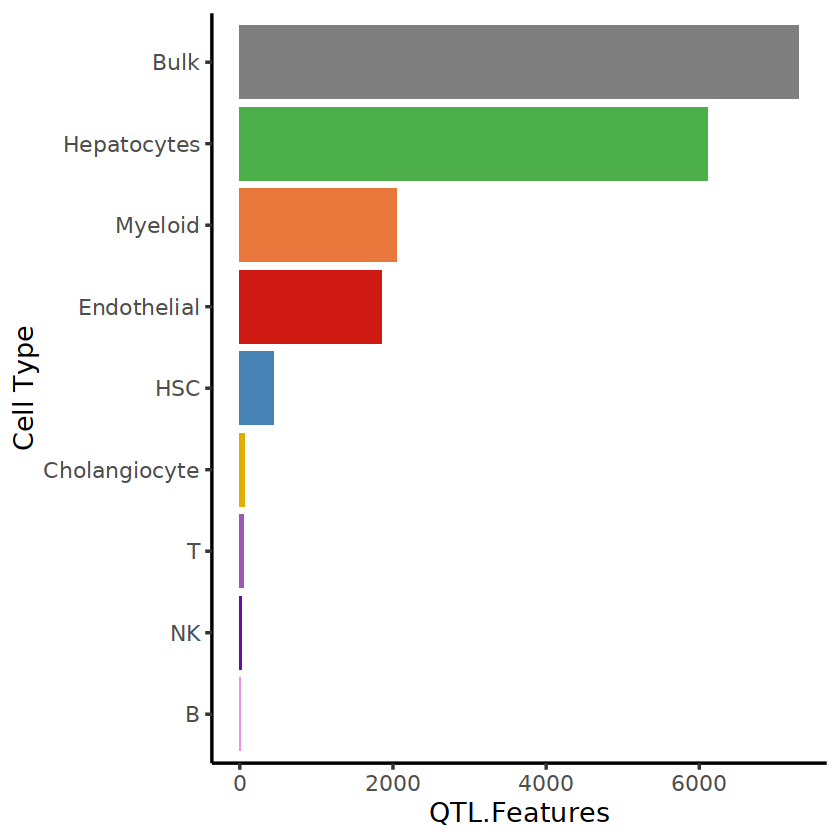

In [18]:
ggplot(summary.df, aes(y=cell, x=features.sig, fill=cell)) + geom_col() + 
    scale_fill_manual(values=celltype_colors) + theme_classic(base_size=16) + 
    labs(fill='Cell Type', x='QTL.Features', y='Cell Type') + theme(legend.position="none")

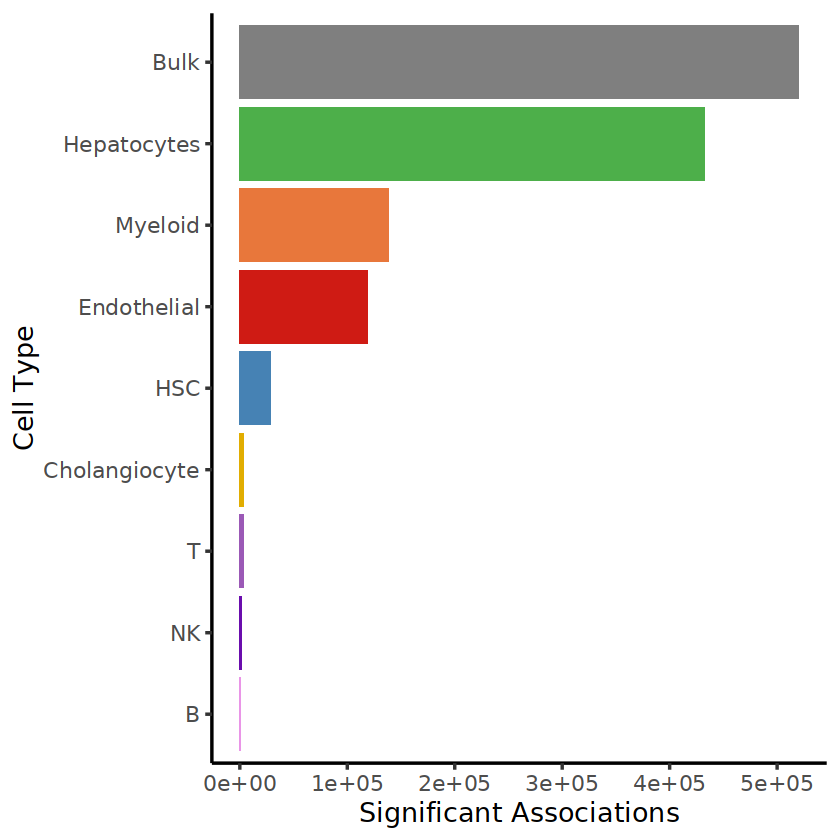

In [19]:
ggplot(summary.df, aes(y=cell, x=tests.sig, fill=cell)) + geom_col() + 
    scale_fill_manual(values=celltype_colors) + theme_classic(base_size=16) + 
    labs(fill='Cell Type', x='Significant Associations', y='Cell Type') + theme(legend.position="none")